Predictive Linear Regression Model Pipeline

The objective of this task is to build a supervised machine learning
regression model that predicts house prices.
Techniques Used

- Data loading using Scikit-Learn
- Exploratory data analysis
- Missing value handling
- Mean imputation
- Categorical encoding
- Feature scaling
- Train-test split
- Ridge Regression
- R² evaluation
- RMSE evaluation
- Actual vs Predicted visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

Load Dataset

The House Prices dataset is used for this regression task.
The target variable is SalePrice, which represents the sale price
of a house.

In [2]:
# Load the House Prices dataset
data = fetch_openml(name="house_prices", as_frame=True)

df = data.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 81


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")
print(missing_values.head(20))

Columns containing missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
X = df.drop("SalePrice", axis=1)
y = pd.to_numeric(df["SalePrice"])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [9]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 37
Number of categorical features: 43


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 80)
Testing features: (292, 80)
Training target: (1168,)
Testing target: (292,)


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [12]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
ridge_model = Ridge(alpha=1.0)

print("Ridge Regression model created.")

Ridge Regression model created.


In [15]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", ridge_model)
])

print("Complete machine learning pipeline created.")

Complete machine learning pipeline created.


In [16]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[156834.21702035 341536.92457446  92179.10362271 178356.65467959
 326805.62960518  62475.59005724 245009.49694254 148576.46621027
  54791.21038444 153418.44808121]


In [18]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8842862711154871


In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 29791.979578306396


In [20]:
print("=" * 40)
print("TASK 2 - MODEL EVALUATION")
print("=" * 40)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")

TASK 2 - MODEL EVALUATION
R² Score : 0.8843
RMSE     : 29791.98


In [21]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,154500,156834.217020
1,325000,341536.924574
2,115000,92179.103623
3,159000,178356.654680
4,315500,326805.629605
5,75500,62475.590057
6,311500,245009.496943
7,146000,148576.466210
8,84500,54791.210384
9,135500,153418.448081


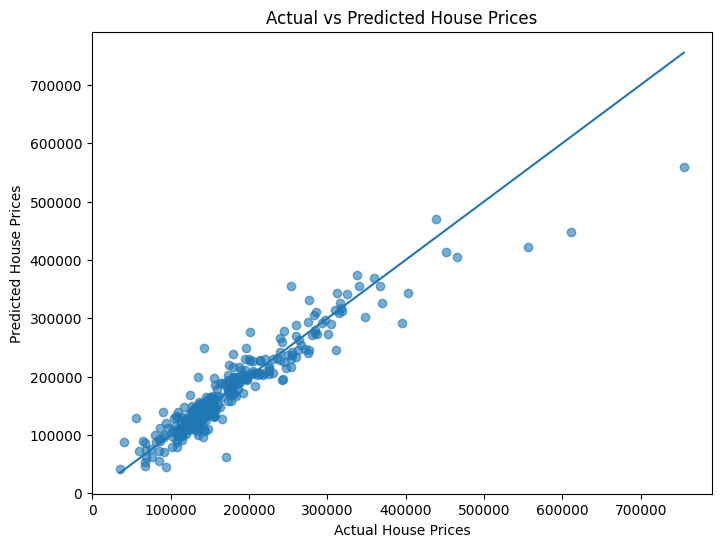

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

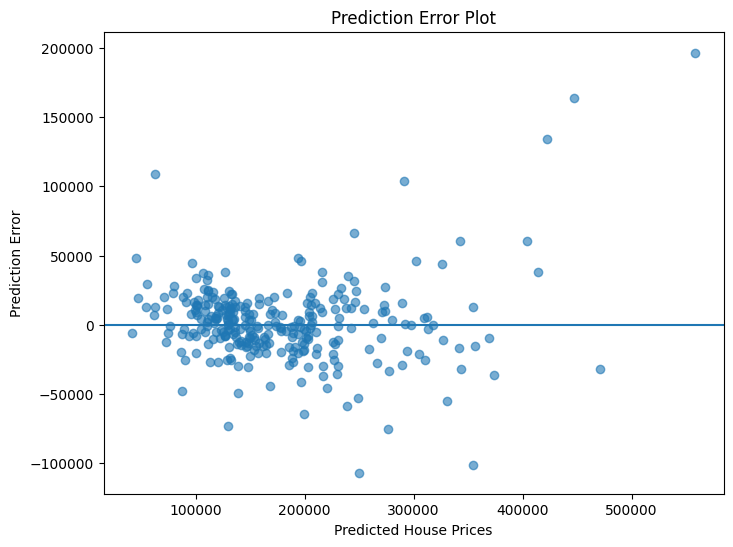

In [23]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors, alpha=0.6)

plt.axhline(y=0)

plt.xlabel("Predicted House Prices")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Plot")

plt.show()

Final Results

The Ridge Regression model was evaluated using two metrics:

- R² Score
- Root Mean Squared Error (RMSE)

The model predictions were also compared with actual house prices
using visualization.

In [24]:
print("FINAL TASK 2 RESULTS")
print("--------------------")
print("Model: Ridge Regression")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

FINAL TASK 2 RESULTS
--------------------
Model: Ridge Regression
R² Score: 0.8843
RMSE: 29791.98


In [25]:
print("FINAL TASK 2 RESULTS")
print("--------------------")
print("Model: Ridge Regression")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

FINAL TASK 2 RESULTS
--------------------
Model: Ridge Regression
R² Score: 0.8843
RMSE: 29791.98


A supervised regression pipeline was successfully developed to predict
house prices.

The dataset was divided into training and testing sets. Numerical
features were processed using mean imputation and standard scaling.
Categorical features were handled using imputation and one-hot encoding.

A Ridge Regression model was trained using the processed features.
The model was evaluated using R² and RMSE.

The actual and predicted house prices were also visualized to understand
the model's prediction performance.

This task demonstrates a complete machine learning regression workflow
from data preprocessing to model evaluation.

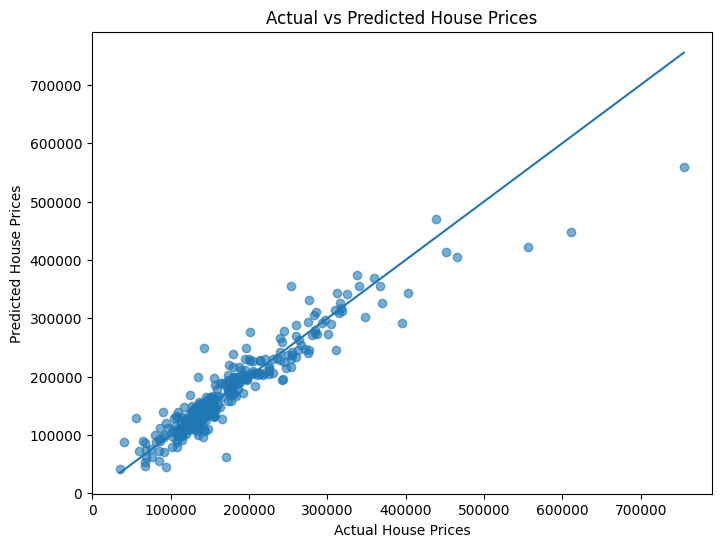

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

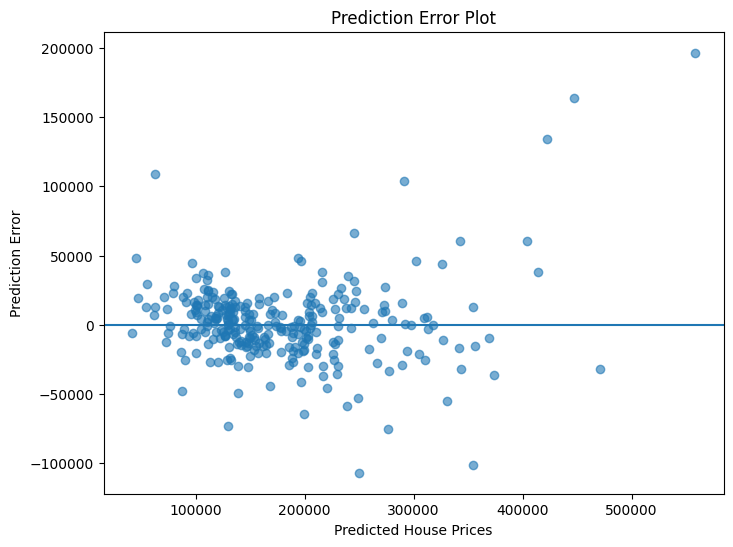

In [27]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors, alpha=0.6)

plt.axhline(y=0)

plt.xlabel("Predicted House Prices")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Plot")

plt.savefig("prediction_error.png", dpi=300, bbox_inches="tight")

plt.show()